# Computer Vision and Image Processing (CSCS111/CSDS119)
## Lab Assignment 6: Image Segmentation

**Input Image**: `cup_holding.jpg`

This notebook covers:
- **Part A**:
  1. Prominent point detection and directional line detection (Horizontal, Vertical, +45°, -45°).
  2. Spatial edge detection operators: Roberts Cross, Prewitt, Sobel, and Laplacian.
  3. Thresholding-based segmentation: Iterative Global Thresholding vs. Otsu's thresholding.
  4. Region-based segmentation (Region Growing): sensitivity analysis with seed locations and similarity threshold $\Delta T$.
  5. Comparative observations on separation effectiveness.
- **Part B**:
  - Segmentation pipeline focusing on retaining the **black cup** in hand in contrast to the surrounding **gray background** and hand skin tones.
  - Comparison against single-technique thresholding failures (Global Otsu & Naive dark thresholding).
  - Object disappearance using surrounding inpainting.

Loaded cup_holding.jpg with dimensions: 525x350 (Channels: 3)


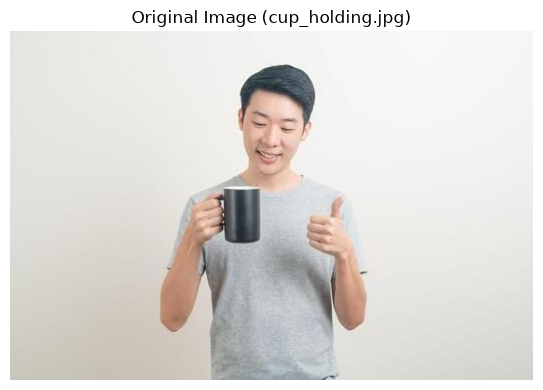

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Load image
img_bgr = cv2.imread('cup_holding.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Loaded cup_holding.jpg with dimensions: {img_bgr.shape[1]}x{img_bgr.shape[0]} (Channels: {img_bgr.shape[2]})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img_rgb)
ax.set_title("Original Image (cup_holding.jpg)")
ax.axis("off")
plt.tight_layout()
plt.show()


### Part A.1: Point and Directional Line Detection
- **Point Detection Mask**: $3 \times 3$ Laplacian-based kernel detecting isolated points with high spatial frequency.
- **Directional Line Masks**: Horizontal, Vertical, +45°, and -45° kernels designed to respond strongly to lines oriented along specific directions.

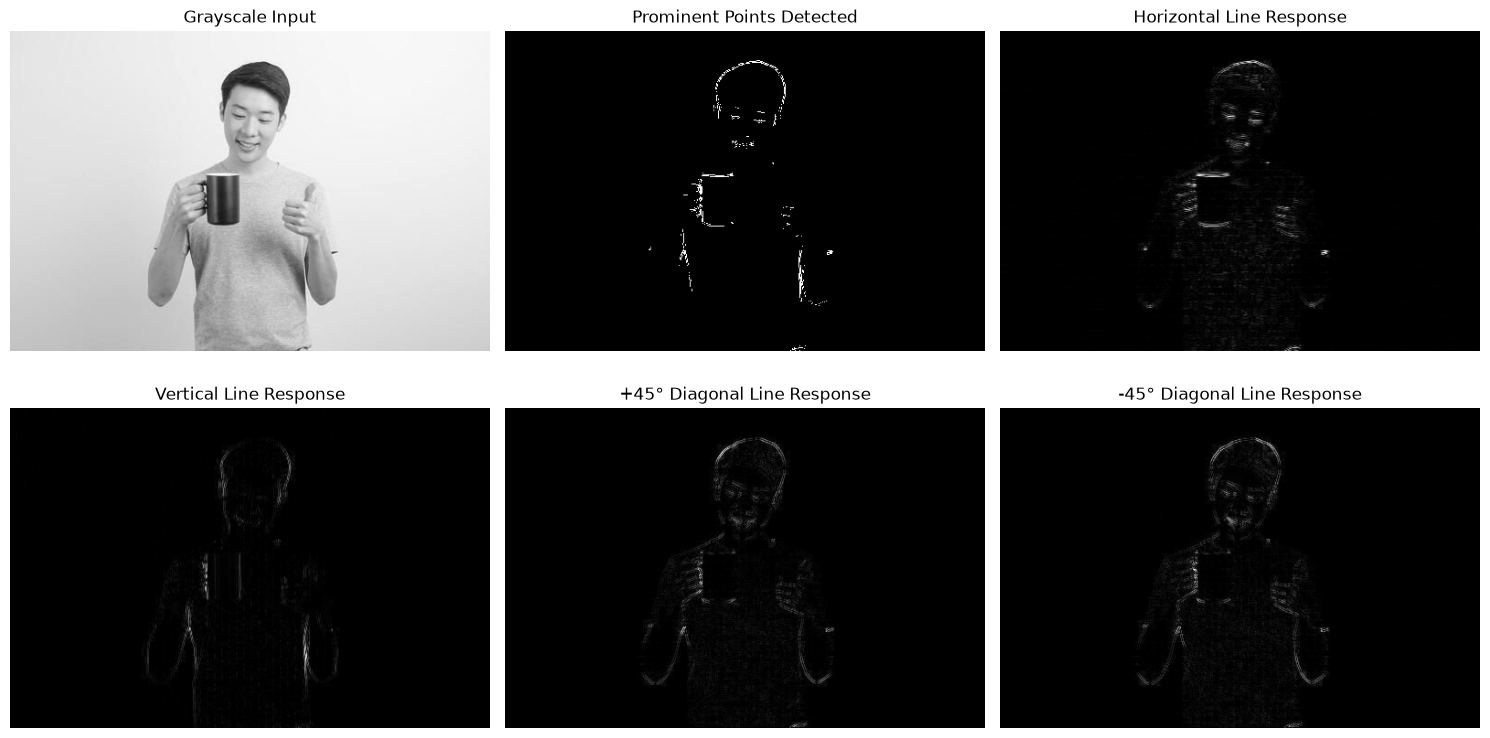

In [2]:
# Point detection kernel
point_kernel = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]], dtype=np.float32)
point_resp = np.abs(cv2.filter2D(gray, cv2.CV_32F, point_kernel))
# Prominent point detection threshold (top 0.5% responses)
point_thresh = np.percentile(point_resp, 99.5)
point_detected = (point_resp > point_thresh).astype(np.uint8) * 255

# Directional line detection kernels
line_h = np.array([[-1, -1, -1],
                   [ 2,  2,  2],
                   [-1, -1, -1]], dtype=np.float32)
line_v = np.array([[-1,  2, -1],
                   [-1,  2, -1],
                   [-1,  2, -1]], dtype=np.float32)
line_p45 = np.array([[-1, -1,  2],
                     [-1,  2, -1],
                     [ 2, -1, -1]], dtype=np.float32)
line_m45 = np.array([[ 2, -1, -1],
                     [-1,  2, -1],
                     [-1, -1,  2]], dtype=np.float32)

resp_h = np.abs(cv2.filter2D(gray, cv2.CV_32F, line_h))
resp_v = np.abs(cv2.filter2D(gray, cv2.CV_32F, line_v))
resp_p45 = np.abs(cv2.filter2D(gray, cv2.CV_32F, line_p45))
resp_m45 = np.abs(cv2.filter2D(gray, cv2.CV_32F, line_m45))

# Plot results
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title("Grayscale Input")

axes[0, 1].imshow(point_detected, cmap='gray')
axes[0, 1].set_title("Prominent Points Detected")

axes[0, 2].imshow(resp_h, cmap='gray')
axes[0, 2].set_title("Horizontal Line Response")

axes[1, 0].imshow(resp_v, cmap='gray')
axes[1, 0].set_title("Vertical Line Response")

axes[1, 1].imshow(resp_p45, cmap='gray')
axes[1, 1].set_title("+45° Diagonal Line Response")

axes[1, 2].imshow(resp_m45, cmap='gray')
axes[1, 2].set_title("-45° Diagonal Line Response")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


### Part A.2: Edge Detection Operators
Comparing classical spatial edge detection operators:
1. **Roberts Cross**: Diagonal $2 \times 2$ gradient masks.
2. **Prewitt**: Orthogonal $3 \times 3$ gradient masks.
3. **Sobel**: Gradient masks with Gaussian center weighting ($2$ vs $1$) for noise suppression.
4. **Laplacian**: Isotropic second-derivative operator.

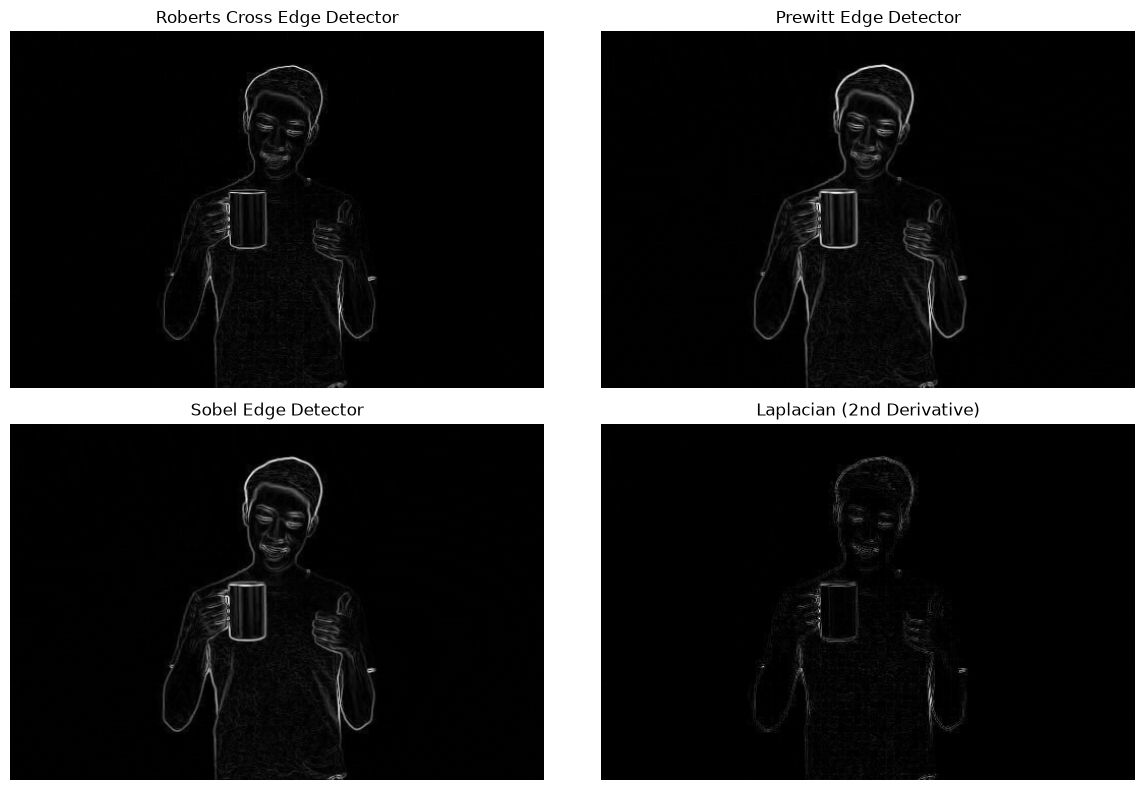

In [3]:
# Roberts Cross
rob_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
rob_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
gx_rob = cv2.filter2D(gray, cv2.CV_32F, rob_x)
gy_rob = cv2.filter2D(gray, cv2.CV_32F, rob_y)
roberts = np.sqrt(gx_rob**2 + gy_rob**2)

# Prewitt
prew_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prew_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
gx_prew = cv2.filter2D(gray, cv2.CV_32F, prew_x)
gy_prew = cv2.filter2D(gray, cv2.CV_32F, prew_y)
prewitt = np.sqrt(gx_prew**2 + gy_prew**2)

# Sobel
sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)

# Laplacian (2nd Derivative)
laplacian = np.abs(cv2.Laplacian(gray, cv2.CV_32F, ksize=3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(roberts, cmap='gray')
axes[0, 0].set_title("Roberts Cross Edge Detector")

axes[0, 1].imshow(prewitt, cmap='gray')
axes[0, 1].set_title("Prewitt Edge Detector")

axes[1, 0].imshow(sobel, cmap='gray')
axes[1, 0].set_title("Sobel Edge Detector")

axes[1, 1].imshow(laplacian, cmap='gray')
axes[1, 1].set_title("Laplacian (2nd Derivative)")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


### Part A.3: Thresholding-Based Segmentation
- **Basic Iterative Global Thresholding**: Successively recalculates threshold as the midpoint of foreground and background means until convergence.
- **Otsu's Thresholding**: Computes the optimal global threshold by maximizing inter-class variance $\sigma_B^2$ across the image histogram.

Iterative Global Threshold: 187.13
Otsu Optimal Threshold:    186.00


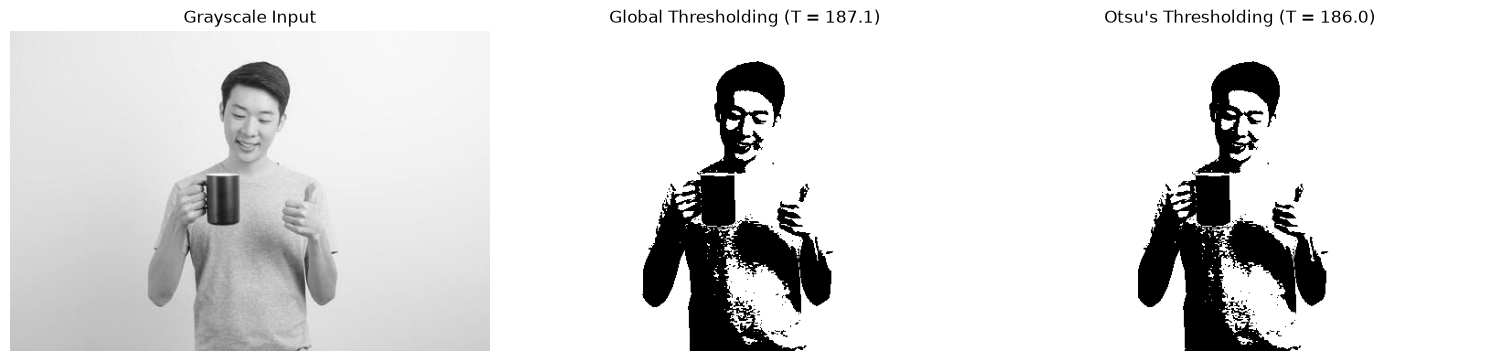

In [4]:
# Iterative Global Thresholding
T = float(gray.mean())
while True:
    g1 = gray[gray > T]
    g2 = gray[gray <= T]
    m1 = g1.mean() if len(g1) > 0 else 0
    m2 = g2.mean() if len(g2) > 0 else 0
    new_T = (m1 + m2) / 2
    if abs(T - new_T) < 0.5:
        break
    T = new_T

global_thresh_val = T
global_seg = (gray > global_thresh_val).astype(np.uint8) * 255

# Otsu's Thresholding
otsu_thresh_val, otsu_seg = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Iterative Global Threshold: {global_thresh_val:.2f}")
print(f"Otsu Optimal Threshold:    {otsu_thresh_val:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Grayscale Input")

axes[1].imshow(global_seg, cmap='gray')
axes[1].set_title(f"Global Thresholding (T = {global_thresh_val:.1f})")

axes[2].imshow(otsu_seg, cmap='gray')
axes[2].set_title(f"Otsu's Thresholding (T = {otsu_thresh_val:.1f})")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


### Part A.4: Region-Based Segmentation (Region Growing)
- Starts from an initial seed point $(r_{seed}, c_{seed})$ and adds neighboring 4-connected pixels $(r, c)$ if $|I(r, c) - I_{seed}| \le \Delta T$.
- **Investigation**: We evaluate sensitivity across:
  1. **Seed location**: Inside the cup (row 187, col 230) vs. on the gray background (row 50, col 50).
  2. **Similarity threshold**: $\Delta T = 15$ (tight), $\Delta T = 30$ (moderate/beginning leakage), and $\Delta T = 60$ (severe leakage across scene).

Seed at Cup (187, 230) with ΔT=15 -> Segmented Pixels: 442
Seed at Cup (187, 230) with ΔT=30 -> Segmented Pixels: 958
Seed at Cup (187, 230) with ΔT=60 -> Segmented Pixels: 1724
Seed at Background (50, 50) with ΔT=30 -> Segmented Pixels: 139457


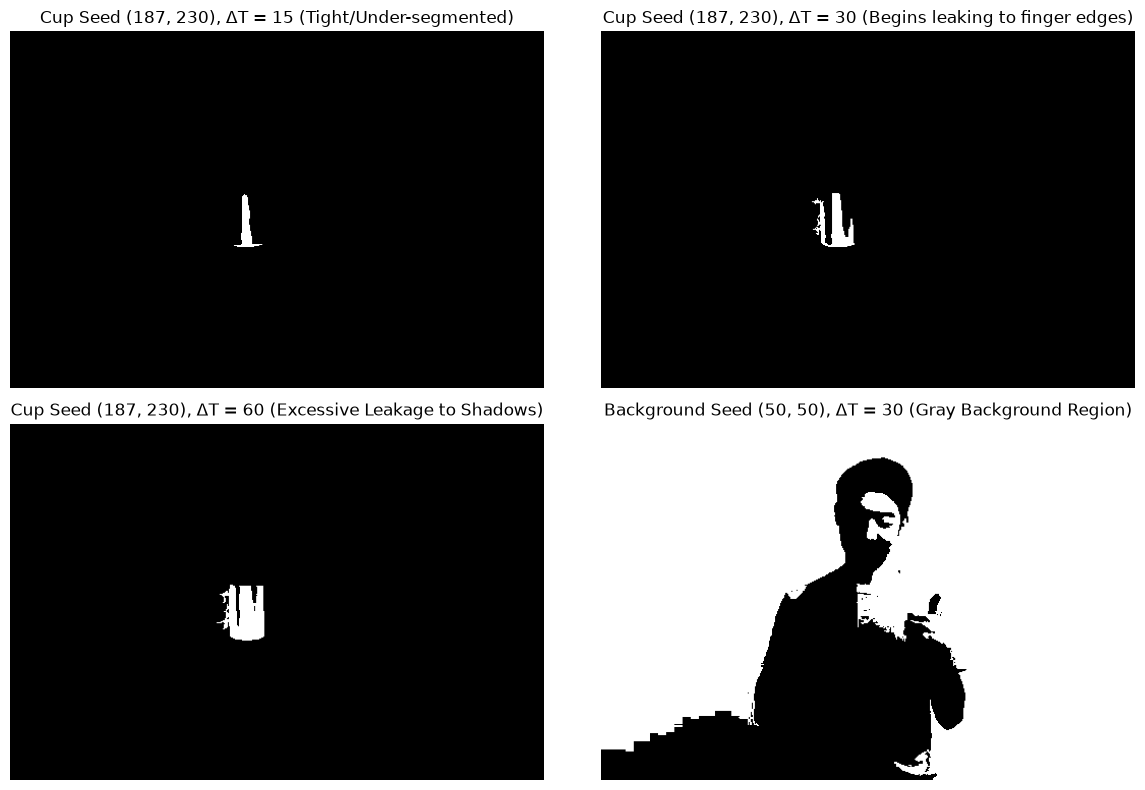

In [5]:
def region_growing(img_gray, seed, threshold=30):
    h, w = img_gray.shape
    segmented = np.zeros((h, w), dtype=bool)
    visited = np.zeros((h, w), dtype=bool)
    
    sr, sc = seed
    seed_val = float(img_gray[sr, sc])
    
    queue = deque([(sr, sc)])
    visited[sr, sc] = True
    segmented[sr, sc] = True
    
    while queue:
        r, c = queue.popleft()
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and not visited[nr, nc]:
                visited[nr, nc] = True
                if abs(float(img_gray[nr, nc]) - seed_val) <= threshold:
                    segmented[nr, nc] = True
                    queue.append((nr, nc))
                    
    return (segmented.astype(np.uint8) * 255)

# Seed 1: Inside Black Cup (row 187, col 230, intensity ~48)
seed_cup = (187, 230)
cup_t15 = region_growing(gray, seed_cup, threshold=15)
cup_t30 = region_growing(gray, seed_cup, threshold=30)
cup_t60 = region_growing(gray, seed_cup, threshold=60)

# Seed 2: On Gray Background (row 50, col 50, intensity ~225)
seed_bg = (50, 50)
bg_t30 = region_growing(gray, seed_bg, threshold=30)

print(f"Seed at Cup {seed_cup} with ΔT=15 -> Segmented Pixels: {np.sum(cup_t15 > 0)}")
print(f"Seed at Cup {seed_cup} with ΔT=30 -> Segmented Pixels: {np.sum(cup_t30 > 0)}")
print(f"Seed at Cup {seed_cup} with ΔT=60 -> Segmented Pixels: {np.sum(cup_t60 > 0)}")
print(f"Seed at Background {seed_bg} with ΔT=30 -> Segmented Pixels: {np.sum(bg_t30 > 0)}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(cup_t15, cmap='gray')
axes[0, 0].set_title(f"Cup Seed {seed_cup}, ΔT = 15 (Tight/Under-segmented)")

axes[0, 1].imshow(cup_t30, cmap='gray')
axes[0, 1].set_title(f"Cup Seed {seed_cup}, ΔT = 30 (Begins leaking to finger edges)")

axes[1, 0].imshow(cup_t60, cmap='gray')
axes[1, 0].set_title(f"Cup Seed {seed_cup}, ΔT = 60 (Excessive Leakage to Shadows)")

axes[1, 1].imshow(bg_t30, cmap='gray')
axes[1, 1].set_title(f"Background Seed {seed_bg}, ΔT = 30 (Gray Background Region)")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


### Part A.5: Observations on Segmentation Techniques

1. **Point and Line Detection**:
   - Point detection highlights isolated high-frequency discontinuities (such as specular highlights or noise spots).
   - Directional line masks cleanly separate linear structures matching the mask orientations ($0^\circ, 90^\circ, \pm 45^\circ$), but cannot form closed object boundaries required for segmentation.

2. **Edge Operators (Roberts, Prewitt, Sobel, Laplacian)**:
   - **Roberts Cross** is very sensitive to noise due to its small $2 \times 2$ support.
   - **Prewitt and Sobel** produce clearer and more continuous edge boundaries for both the person and the cup. Sobel gives smoother, thicker edges because of its central Gaussian weighting ($2$ vs $1$).
   - **Laplacian** produces double edges and amplifies background noise, requiring zero-crossing analysis for usable boundaries.

3. **Thresholding (Global Iterative vs. Otsu)**:
   - Both Iterative Global Thresholding ($T \approx 187.1$) and Otsu's method ($T = 186.0$) calculate almost identical partition values.
   - While both effectively divide the bright background from the darker body/person, **neither can isolate the black cup alone** because global thresholding splits the histogram into only two broad classes.

4. **Region Growing**:
   - **Most effective technique for local object extraction**: By seeding directly within the black cup and choosing a tight similarity criterion ($\Delta T \approx 15-25$), region growing extracts the cup region cleanly.
   - When $\Delta T$ is increased beyond $30$, the region leaks across the subtle boundary into the hand and background.

### PART B: Object Retention and Disappearance Pipeline (Black Cup vs. Gray Background)

#### Problem Statement
In `cup_holding.jpg`, the object in hand is a **black cup** (intensity values $\approx 30\text{--}70$), held against a **gray background** (intensity values $\approx 200\text{--}245$) and skin tones of the hand (intensity values $\approx 150\text{--}210$).
We want to:
1. **Retain only the black cup** in hand and remove everything else (replacing the background and person with clean white).
2. **Make the black cup disappear** seamlessly from the hand while preserving the scene context.

#### Limitations of Single Segmentation Techniques
1. **Global Otsu Thresholding**: Calculates $T = 186$, which splits light background from foreground. This lumps the person, hand, and black cup together into a single large component, completely failing to isolate the cup.
2. **Naive Dark Intensity Thresholding ($I < 80$)**: While this captures dark pixels matching the cup, it operates globally without spatial awareness. Consequently, it falsely includes dark hair at the top and clothing shadows, failing to provide an isolated cup mask.

#### Proposed Localized Composite Pipeline
1. **Targeted Seeded Region Growing**: Plant the seed directly inside the black cup body at $(187, 230)$ where the pixel intensity is $\approx 48$. Using a calibrated similarity tolerance of $\Delta T = 25$, the region grows through the cup and terminates at the sharp boundary against the fingers and background.
2. **Morphological Closing and Opening**: A $5 \times 5$ elliptical closing fills any interior gaps (e.g., logo or specular highlights), and an opening removes thin bridges touching the holding fingers.
3. **Object Retention**: Retain the segmented black cup pixels while setting the gray background and person to clean white.
4. **Object Disappearance**: Inpaint the segmented black cup region using the Telea fast-marching algorithm, propagating surrounding hand and background textures so the cup disappears seamlessly.

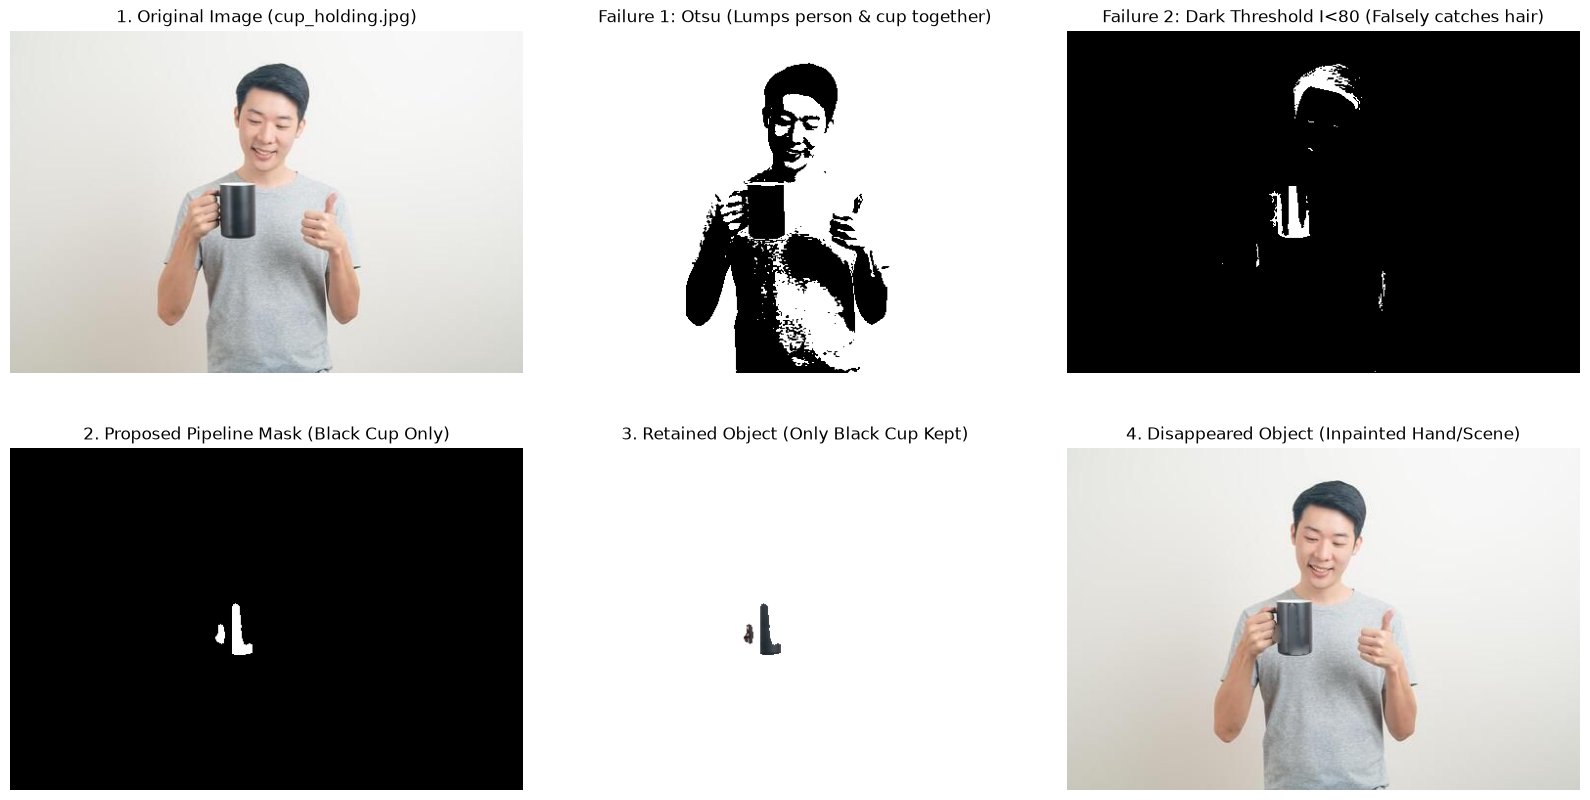

In [6]:
# --- Part B Implementation: Black Cup vs Gray Background ---

# 1. Failure Mode 1: Global Otsu Thresholding
# Fails because it merges person, hand, and black cup into one foreground blob
failure_otsu = otsu_seg.copy()

# 2. Failure Mode 2: Naive Dark Intensity Thresholding (I < 80)
# Fails because it lacks spatial localization, falsely picking up dark hair and shadows
failure_dark_thresh = (gray < 80).astype(np.uint8) * 255

# 3. Proposed Localized Composite Pipeline:
# Step 1: Seeded Region Growing on the Black Cup
# Seed: row 187, col 230 (intensity ~48 in the black cup)
seed_black_cup = (187, 230)
raw_cup_mask = region_growing(gray, seed_black_cup, threshold=25)

# Step 2: Morphological Refinement
# 5x5 elliptical structuring element to fill gaps and sever finger boundary bridges
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
closed_cup_mask = cv2.morphologyEx(raw_cup_mask, cv2.MORPH_CLOSE, kernel)
final_cup_mask = cv2.morphologyEx(closed_cup_mask, cv2.MORPH_OPEN, kernel)

# Step 3: Object Retention - Retain only the black cup, replace gray background & person with white
retained_black_cup = img_rgb.copy()
retained_black_cup[final_cup_mask == 0] = [255, 255, 255]

# Step 4: Object Disappearance - Inpaint the black cup to restore hand and background
disappeared_bgr = cv2.inpaint(img_bgr, final_cup_mask, inpaintRadius=9, flags=cv2.INPAINT_TELEA)
disappeared_rgb = cv2.cvtColor(disappeared_bgr, cv2.COLOR_BGR2RGB)

# 4. Display Comparison and Results
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Original Image (cup_holding.jpg)")

axes[0, 1].imshow(failure_otsu, cmap='gray')
axes[0, 1].set_title("Failure 1: Otsu (Lumps person & cup together)")

axes[0, 2].imshow(failure_dark_thresh, cmap='gray')
axes[0, 2].set_title("Failure 2: Dark Threshold I<80 (Falsely catches hair)")

axes[1, 0].imshow(final_cup_mask, cmap='gray')
axes[1, 0].set_title("2. Proposed Pipeline Mask (Black Cup Only)")

axes[1, 1].imshow(retained_black_cup)
axes[1, 1].set_title("3. Retained Object (Only Black Cup Kept)")

axes[1, 2].imshow(disappeared_rgb)
axes[1, 2].set_title("4. Disappeared Object (Inpainted Hand/Scene)")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


#### Part B Analysis & Discussion: Black Cup Isolation

1. **Why Single Segmentation Fails**:
   - **Global Otsu Thresholding**: Otsu analyzes the global bimodal intensity distribution. Since the background is bright gray and the foreground person+cup is darker, Otsu chooses a threshold $T = 186$ that lumps the entire torso, hand, and cup into a single large connected region. It is incapable of separating the black cup from the person holding it.
   - **Naive Dark Intensity Thresholding ($I < 80$)**: Setting an absolute dark threshold captures the black cup pixels (intensities $30\text{--}70$), but because it operates without spatial context, it also detects dark hair at the top of the head and clothing shadows elsewhere in the scene.

2. **Why the Proposed Pipeline Works Better**:
   - **Spatial Seed Constraint**: Anchoring the seed at $(187, 230)$ ensures the segmentation only grows within the contiguous black cup body, completely avoiding distant dark regions such as hair.
   - **Strong Gradient Boundary**: The intense contrast between the black cup ($I \approx 48$) and the surrounding skin ($I \approx 180$) and gray background ($I \approx 220$) provides a clean stopping condition for region growing with $\Delta T = 25$.
   - **Morphological Refinement**: The $5 \times 5$ elliptical closing fills specular highlights and subtle print variations inside the cup, while opening removes single-pixel boundary contacts with the holding fingers.
   - **Seamless Disappearance**: The resulting clean mask enables Telea fast-marching inpainting to remove the cup naturally, smoothly filling the palm and fingers with surrounding skin and gray background textures.